In [29]:
import pandas as pd
import numpy as np

In [30]:
data = pd.read_csv('/content/drive/MyDrive/Current semester materials/CSE 422/Datasets/Ford Car Price Prediction.csv')
data.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,NaN,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,NaN,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,NaN,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,NaN,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,NaN,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,NaN,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,NaN,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,NaN,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,NaN,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145.0,61.4,1.0


In [31]:
data.shape

(17966, 9)

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17957 non-null  float64
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(3), int64(3), object(3)
memory usage: 1.2+ MB


In [33]:
data.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,9
mpg,0
engineSize,0


In [34]:
data.duplicated().sum()

154

In [35]:
data['tax'].fillna(data['tax'].mean(), inplace=True)

data.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,113.312747,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,113.312747,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,113.312747,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,113.312747,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,113.312747,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,113.312747,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,113.312747,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,113.312747,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,113.312747,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145.000000,61.4,1.0


In [36]:
data.shape

(17966, 9)

In [37]:
data.drop_duplicates(inplace=True)

data.shape

(17812, 9)

In [38]:
categorical_columns = ['model', 'transmission', 'fuelType']
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

data

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,113.312747,57.7,1.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2018,14000,9083,113.312747,57.7,1.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,13000,12456,113.312747,57.7,1.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,2019,17500,10460,113.312747,40.3,1.5,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,2019,16500,1482,113.312747,48.7,1.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150.000000,47.1,1.4,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,2014,7499,40700,30.000000,57.7,1.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,2015,9999,7010,20.000000,67.3,1.6,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,2018,8299,5007,145.000000,57.7,1.2,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_columns = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

In [40]:
data

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,12000,-0.382994,0.000235,-0.020597,-0.810561,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,0.554393,14000,-0.736317,0.000235,-0.020597,-0.810561,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.067059,13000,-0.562616,0.000235,-0.020597,-0.810561,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,1.041726,17500,-0.665405,0.000235,-1.737858,0.345325,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,1.041726,16500,-1.127749,0.000235,-0.908836,-0.810561,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,8999,-0.344061,0.591695,-1.066745,0.114148,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,-1.394942,7499,0.891875,-1.342906,-0.020597,-0.810561,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,-0.907608,9999,-0.843071,-1.504122,0.926858,0.576502,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,0.554393,8299,-0.946220,0.511087,-0.020597,-0.348206,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [41]:
corr_matrix = data.corr().abs()

high_corr_pairs = []

threshold = 0.8
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] < 1 and corr_matrix.iloc[i, j] > threshold:

            feature1 = corr_matrix.columns[i]
            feature2 = corr_matrix.columns[j]
            high_corr_pairs.append((feature1, feature2, corr_matrix.iloc[i, j]))

for pair in high_corr_pairs:
    print(f"Features: {pair[0]} and {pair[1]} | Correlation: {pair[2]:.2f}")


In [42]:
# corr_matrix = data.corr()

# import seaborn as sns

# sns.heatmap(corr_matrix, cmap = 'YlGnBu')

In [43]:
x = data.drop(columns=['price'])
y = data['price']

In [44]:
x

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.000235,-0.020597,-0.810561,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,0.554393,-0.736317,0.000235,-0.020597,-0.810561,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.067059,-0.562616,0.000235,-0.020597,-0.810561,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,1.041726,-0.665405,0.000235,-1.737858,0.345325,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,1.041726,-1.127749,0.000235,-0.908836,-0.810561,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,-0.344061,0.591695,-1.066745,0.114148,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,-1.394942,0.891875,-1.342906,-0.020597,-0.810561,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,-0.907608,-0.843071,-1.504122,0.926858,0.576502,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,0.554393,-0.946220,0.511087,-0.020597,-0.348206,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [45]:
y

,price
0,12000
1,14000
2,13000
3,17500
4,16500
...,...
17961,8999
17962,7499
17963,9999
17964,8299


In [46]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(x_train, y_train)

knn.score(x_test, y_test)

0.02048835251192815

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

LinearRegression()

In [49]:
y_pred = linear_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

In [50]:
mse

3669839.448616289

In [51]:
rmse

1915.682502038448

In [52]:
price_median = np.median(y_train)
y_train_cat = np.where(y_train > price_median, 1, 0)
y_test_cat = np.where(y_test > price_median, 1, 0)

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [54]:
logistic_model = LogisticRegression()
logistic_model.fit(x_train, y_train_cat)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [55]:
y_pred_logistic = logistic_model.predict(x_test)

accuracy = accuracy_score(y_test_cat, y_pred_logistic)

accuracy

0.9040134717934325

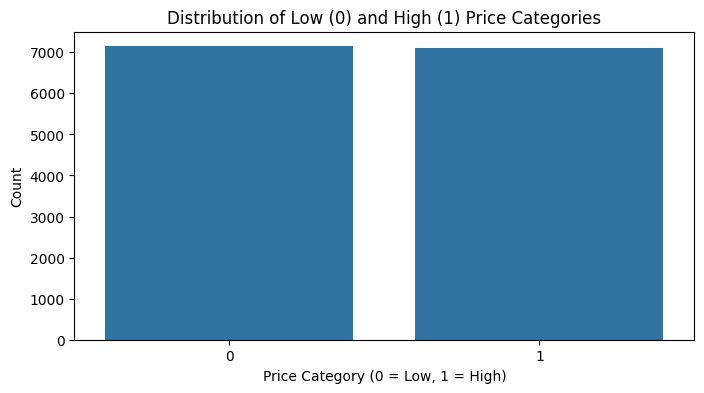

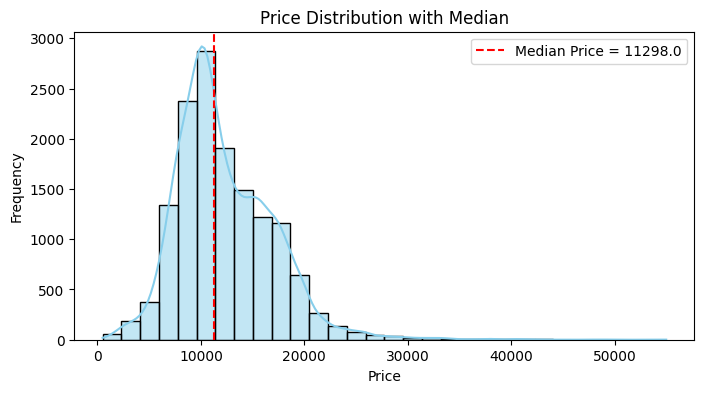

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 4))
sns.countplot(x=y_train_cat)
plt.title('Distribution of Low (0) and High (1) Price Categories')
plt.xlabel('Price Category (0 = Low, 1 = High)')
plt.ylabel('Count')
plt.show()


plt.figure(figsize=(8, 4))
sns.histplot(y_train, bins=30, kde=True, color='skyblue')
plt.axvline(price_median, color='red', linestyle='--', label=f'Median Price = {price_median}')
plt.title('Price Distribution with Median')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()
